# Data Inspection — Quant Data Project (KTT)

### Goals

1. What does each file contain, what is its shape, date range and key coverage?
2. Are the returns (`ret1d`) clean? Are there outliers or bad ticks we must handle later?
3. How big is the **trading universe** (`in_trading_universe == 'Y'`) and how does it evolve?
4. For each signal `d1..d11`: coverage and distribution.
5. A first **forecast-power** read: cross-sectional **Information Coefficient (IC)** of each signal
   vs. the *next earnable* return, respecting the data-availability timing.
6. How correlated are the signals with each other and with the risk factors?
7. Risk factors


### Timing convention
All values (`d*`, `rf*`, `ret1d`, `in_trading_universe`, ...) are available **after market close**
on their `data_date`. `ret1d(i,t)` is the close(t-1)→close(t) return.

So a signal observed on day `t` only becomes known **after** close(t) — the close(t) auction has already
happened, so we cannot trade on it then. The first close we can transact at is close(t+1), and the first
full return we can earn is `ret1d(i, t+2)` (close `t+1` → close `t+2`). **Every predictive-power check
below aligns signal at `t` with `ret1d` at `t + LAG` (`LAG = 2` trading days)** to avoid look-ahead bias.

In [1]:
import os, glob, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.6g}")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

DATA_DIR = "."  # all csv files live next to this notebook

REF_FILES = ["security_reference_data_w_ret1d_1.csv",
              "security_reference_data_w_ret1d_2.csv"]
RF_FILES = ["risk_factors_1.csv", "risk_factors_2.csv"]

DS_FILES = [f"data_set_{i+1}.csv" for i in range(11)]

## 1 Security Reference Data
### 1.1 Load security reference data

In [2]:
#| label: tbl-ref-ranges
#| tbl-cap: "Numeric-column ranges in the reference data"
def to_dt(yyyymmdd):
    """int YYYYMMDD -> pandas datetime."""
    return pd.to_datetime(yyyymmdd.astype("int64").astype(str), format="%Y%m%d")

# Check range of values in numeric columns in reference files
# And downcast if necessary to avoid memory issues when loading
numeric_cols = ["data_date", "security_id", "close_price", "volume", "group_id","ret1d"]
for col in numeric_cols:
    for i in [1,2]:
        raw = pd.read_csv(os.path.join(DATA_DIR, f"security_reference_data_w_ret1d_{i}.csv"), usecols=numeric_cols)
        s = raw[col].dropna()
        mi, ma = s.min(), s.max()
        if pd.api.types.is_integer_dtype(s) or s.apply(float.is_integer).all():
            print(f"  {col:>12} {i}: INT min={int(mi):,}  max={int(ma):,} nan_count={raw[col].isna().sum():,}")
        else:
            max_dec = int(np.nanmax(s.astype(str).str.extract(r'\.(\d+)')[0].str.len()))
            print(f"  {col:>12} {i}: FLOAT min={mi:.6g}  max={ma:.6g}  max_num_decimals={max_dec}  max_abs={s.abs().max():.6g} nan_count={raw[col].isna().sum():,}")


REF_DTYPE = {"data_date":"int32", 
             "security_id":"int32", 
             "close_price":"float32",
             "volume":"float32", 
             "group_id":"int32",
             "in_trading_universe":"category", 
             "ret1d":"float32"}

parts = [pd.read_csv(os.path.join(DATA_DIR, f), dtype=REF_DTYPE) for f in REF_FILES]
ref = pd.concat(parts, ignore_index=True)
print(f"Duplicates in concatenated data: {ref.duplicated(['data_date', 'security_id']).sum()}")
ref = ref.drop_duplicates(["data_date", "security_id"])
ref["date"] = to_dt(ref["data_date"])
print("Shape:", ref.shape)
print("Date range:", ref.data_date.min(), "to", ref.data_date.max())
display(ref.head())

     data_date 1: INT min=20,100,104  max=20,131,231 nan_count=0
     data_date 2: INT min=20,140,102  max=20,171,229 nan_count=0
   security_id 1: INT min=77,901  max=1,116,563,801 nan_count=0
   security_id 2: INT min=1,031  max=1,118,042,001 nan_count=0
   close_price 1: FLOAT min=1.0001  max=141768  max_num_decimals=4  max_abs=141768 nan_count=0
   close_price 2: FLOAT min=1.0001  max=4258.6  max_num_decimals=4  max_abs=4258.6 nan_count=0
        volume 1: INT min=0  max=1,864,158,976 nan_count=0
        volume 2: INT min=1  max=618,237,600 nan_count=0
      group_id 1: INT min=10,101,010  max=55,105,010 nan_count=0
      group_id 2: INT min=10,101,010  max=60,102,040 nan_count=0
         ret1d 1: FLOAT min=-0.856203  max=1099  max_num_decimals=8  max_abs=1099 nan_count=3,557
         ret1d 2: FLOAT min=-0.96512  max=100  max_num_decimals=8  max_abs=100 nan_count=5,297
Duplicates in concatenated data: 0
Shape: (8800015, 8)
Date range: 20100104 to 20171229


,data_date,security_id,close_price,volume,group_id,in_trading_universe,ret1d,date
0,20100104,77901,19.99,"72,728",20102010,N,0.0256542,2010-01-04
1,20100104,78001,23.77,"460,537",20101010,Y,0.0343777,2010-01-04
2,20100104,78401,19.64,1.8471e+06,20104020,Y,0.0282724,2010-01-04
3,20100104,82901,2.8,"219,545",20301010,N,0.0606057,2010-01-04
4,20100104,83501,7.9,"389,291",20201060,N,0.0851647,2010-01-04


### 1.2 Check NaNs

In [3]:
#| label: tbl-ref-schema
#| tbl-cap: "Reference data: dtype, missingness, cardinality"
ref_info = pd.DataFrame({
    "dtype": ref.dtypes.astype(str),
    "# NaN": ref.isna().sum(),
    "% NaN": (ref.isna().mean()*100).round(3),
    "# unique": [ref[c].nunique() for c in ref.columns],
})
display(ref_info)

,dtype,# NaN,% NaN,# unique
data_date,int32,0,0,2013
security_id,int32,0,0,7876
close_price,float32,0,0,128538
volume,float32,0,0,2515877
group_id,int32,0,0,176
in_trading_universe,category,0,0,2
ret1d,float32,8854,0.101,4298865
date,datetime64[us],0,0,2013


### 1.3 Trading universe over time

The portfolio may only hold names with `in_trading_universe == 'Y'`

overall in_trading_universe split:
in_trading_universe
N    4796547
Y    4003468
Name: count, dtype: int64


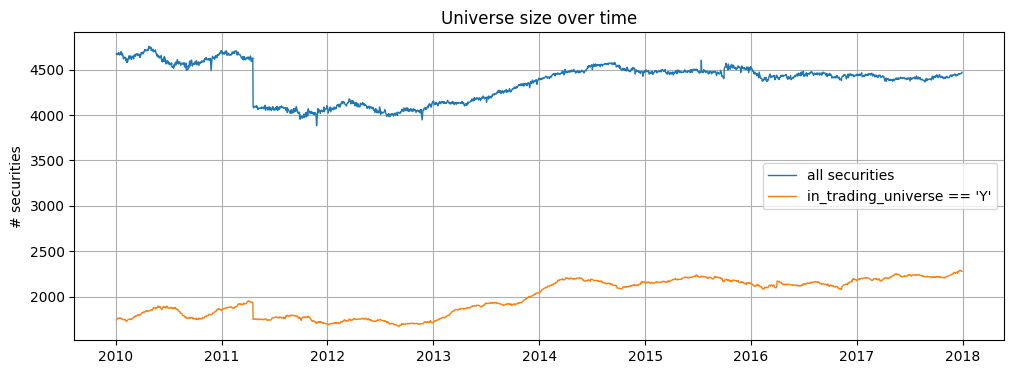

In [4]:
#| label: fig-universe
#| fig-cap: "Trading universe size over time (total vs tradable)"
uni = (ref.assign(is_Y=(ref.in_trading_universe == "Y"))
          .groupby("date")
          .agg(n_total=("security_id","size"), n_tradable=("is_Y","sum")))
print("overall in_trading_universe split:")
print(ref.in_trading_universe.value_counts(dropna=False))

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(uni.index, uni.n_total, label="all securities", lw=1)
ax.plot(uni.index, uni.n_tradable, label="in_trading_universe == 'Y'", lw=1)
ax.set_title("Universe size over time"); ax.set_ylabel("# securities")
ax.legend()
plt.show()

#### Inspecting the 2011–2012 drop in the universe

Largest one-day drops in total universe (2011-2012):
date
2011-04-20   -527
2011-11-25   -119
2012-11-23    -67
2011-09-28    -66
2011-08-16    -54 

Drop on 2011-04-20: total 4628 -> 4101, tradable 1934 -> 1749

Excluded on 2011-04-20: 591
Permanently exclucded: 534
Tradable split of removed: {'N': 351, 'Y': 183}


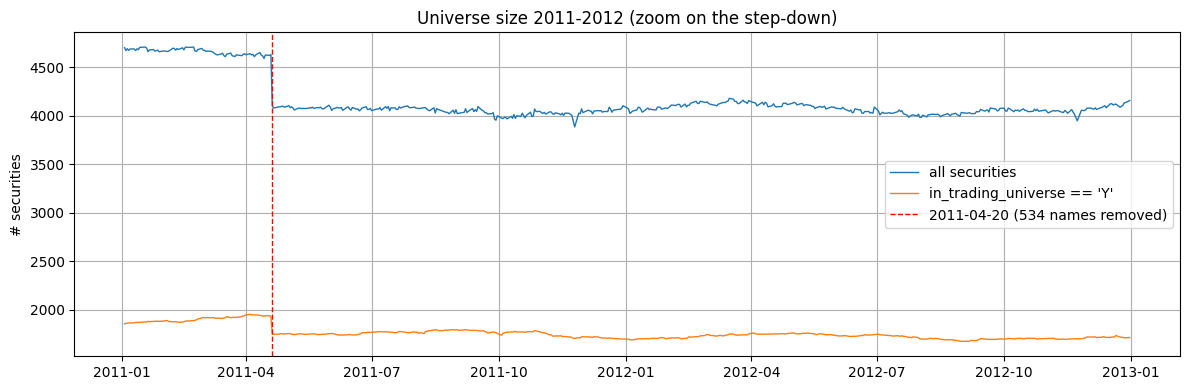

In [5]:
#| label: fig-universe-drop
#| fig-cap: "The 2011–2012 contraction in the universe"
win = uni[(uni.index >= pd.Timestamp("2011-01-01")) & (uni.index <= pd.Timestamp("2012-12-31"))]

delta = win["n_total"].diff()
break_date = delta.idxmin()
print("Largest one-day drops in total universe (2011-2012):")
print(delta.sort_values().head(5).to_string(), "\n")
print(f"Drop on {break_date.date()}: "
      f"total {int(win['n_total'].shift().loc[break_date])} -> {int(win['n_total'].loc[break_date])}, "
      f"tradable {int(win['n_tradable'].shift().loc[break_date])} -> {int(win['n_tradable'].loc[break_date])}\n")

prev_date = win.index[win.index.get_loc(break_date) - 1]
bd, pd_ = int(break_date.strftime("%Y%m%d")), int(prev_date.strftime("%Y%m%d"))
before = ref[ref.data_date == pd_]
after  = ref[ref.data_date == bd]
gone   = set(before.security_id) - set(after.security_id)
ever_later = set(ref.loc[ref.data_date > bd, "security_id"])
perm   = gone - ever_later                       # never seen again after the break
print(f"Excluded on {break_date.date()}: {len(gone)}")
print(f"Permanently exclucded: {len(perm)}")

gb = before[before.security_id.isin(perm)]       # the removed names, as last seen
print("Tradable split of removed:", gb.in_trading_universe.value_counts().to_dict())


fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(win.index, win.n_total, label="all securities", lw=1)
ax.plot(win.index, win.n_tradable, label="in_trading_universe == 'Y'", lw=1)
ax.axvline(break_date, color="red", ls="--", lw=1,
           label=f"{break_date.date()} ({len(perm)} names removed)")
ax.set_title("Universe size 2011-2012 (zoom on the step-down)"); ax.set_ylabel("# securities")
ax.legend(); plt.tight_layout(); plt.show()

### 1.4 Return (`ret1d`) Inspection

count   8.79116e+06
mean    0.000976865
std        0.375352
min        -0.96512
0.1%      -0.173698
1%       -0.0796461
5%       -0.0411564
50%               0
95%       0.0430048
99%       0.0914454
99.9%        0.2415
max           1,099
Name: ret1d, dtype: float64

# NaN ret1d : 8854
# |ret| > 1: 482
# |ret| > 0.5: 2119


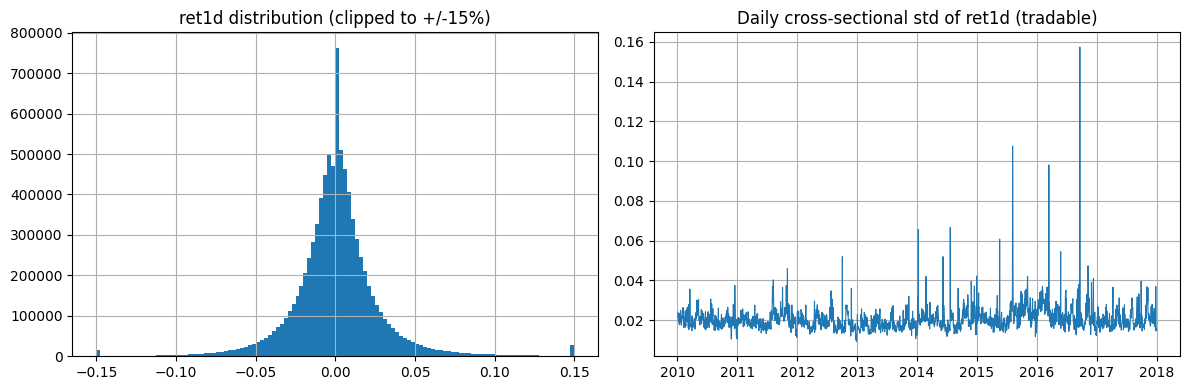

In [6]:
#| label: fig-ret1d-dist
#| fig-cap: "Distribution of daily returns ret1d (clipped for readability)"
r = ref["ret1d"]
print(r.describe(percentiles=[.001,.01,.05,.5,.95,.99,.999]))
print("\n# NaN ret1d :", r.isna().sum())
print("# |ret| > 1:", (r.abs() > 1).sum())
print("# |ret| > 0.5:", (r.abs() > 0.5).sum())

# Distribution clipped to +/-15% just for better visibility of the histogram
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(r.clip(-0.15, 0.15).dropna(), bins=120)
ax[0].set_title("ret1d distribution (clipped to +/-15%)")

tradable = ref[ref.in_trading_universe == "Y"]
daily = tradable.groupby("date")["ret1d"].agg(["mean", "std"])
ax[1].plot(daily.index, daily["std"], lw=0.8)
ax[1].set_title("Daily cross-sectional std of ret1d (tradable)")
plt.tight_layout(); plt.show()

### 1.5 Calculate forward return (target alignment)

A signal `d*(i,t)` is available only **after** the close of day `t`, so the close(t) auction is gone
before we can act. The first close we can trade at is **close(t+1)**, and the first *full* close-to-close
return we can actually own is **close(t+2) = `ret1d(i, t+2)`**. We therefore build
`ret1d_fwd(i, t) = ret1d(i, t + LAG)` with `LAG = 2` by sorting each security by date and shifting the
return up by `LAG` rows. This single table is reused for every forecast-power check below.

In [7]:
#| label: out-fwd-return
ref = ref.sort_values(["security_id", "data_date"])

LAG = 2
# ref["ret1d_fwd"] = ref.groupby("security_id", observed=True)["ret1d"].shift(-LAG)

# For each security, check if there are gaps in reporting (non-consecutive trading days)
all_trading_dates = sorted(ref.data_date.unique())
date_to_idx = {d: i for i, d in enumerate(all_trading_dates)}

gap_report = []
valid_shifts = []
total_chunks = 0
single_chunk_secs = 0
multi_chunk_secs = 0    

for sec_id, grp in ref.groupby("security_id", observed=True):
    if sec_id == 1031:
        print(f"Security {sec_id} before chunking by consecutive trading days:")
        print(grp)
    dates = sorted(grp["data_date"].tolist())
    idxs = [date_to_idx[d] for d in dates]
    
    chunk_id = 0
    chunk_ids = [0]
    for a, b in zip(idxs, idxs[1:]):
        gap = b - a
        if gap > 5: # flag gaps longer than 5 trading days
            gap_report.append({
                "security_id": sec_id,
                "last_date_before_gap": all_trading_dates[a],
                "first_date_after_gap": all_trading_dates[b],
                "gap_trading_days": gap
            })
            chunk_id += 1
        chunk_ids.append(chunk_id)
    
    n_chunks = chunk_id + 1
    total_chunks += n_chunks
    if n_chunks == 1:
        single_chunk_secs += 1
    else:
        multi_chunk_secs += 1

    grp = grp.copy()
    grp["_chunk"] = chunk_ids
    grp["ret1d_fwd"] = grp.groupby("_chunk")["ret1d"].shift(-LAG)
    # if sec_id == 1031:
    #     print(f"Security {sec_id} after chunking:")
    #     print(grp)
    valid_shifts.append(grp.drop(columns="_chunk"))

ref = pd.concat(valid_shifts).sort_values(["security_id", "data_date"])
print(ref[ref.security_id == 1031].head)

gap_df = pd.DataFrame(gap_report)
print(f"Securities with reporting gaps > 5 trading days: {gap_df.security_id.nunique():,}")
print(f"Total gap events: {len(gap_df):,}")
print(f"Total chunks across all securities: {total_chunks:,}")
print(f"Securities with exactly 1 chunk (no gaps): {single_chunk_secs:,}")
print(f"Securities with more than 1 chunk (has gaps > 5 trading days): {multi_chunk_secs:,}")
# display(gap_df.sort_values("gap_trading_days", ascending=False).head(20))

fwd = ref[["data_date", "security_id", "ret1d_fwd", "in_trading_universe"]].copy()
print(f"forward-return frame (LAG={LAG}):", fwd.shape, "| non-null fwd:", fwd.ret1d_fwd.notna().sum())

Security 1031 before chunking by consecutive trading days:
         data_date  security_id  close_price      volume  group_id in_trading_universe       ret1d       date
6034949   20150714         1031        16.42  8.5381e+06  40202010                   N   -0.105665 2015-07-14
6285099   20151001         1031        10.96 1.10404e+07  40202010                   N   -0.024911 2015-10-01
6289600   20151002         1031        11.04 7.01375e+06  40202010                   N  0.00729917 2015-10-02
6294121   20151005         1031        11.48 5.70252e+06  40202010                   N   0.0398552 2015-10-05
6298656   20151006         1031        11.63 5.16928e+06  40202010                   N   0.0130662 2015-10-06
...            ...          ...          ...         ...       ...                 ...         ...        ...
8777707   20171222         1031        13.35 2.53445e+06  40202010                   Y   0.0175305 2017-12-22
8782163   20171226         1031        13.46 1.73678e+06  402

In this example security 1031, first return date is 2015-07-14 and second is 2015-10-01, so lagging by 2 days directly doesn't make sense. We need to for each security_id, find consecutive trading chunks, then calculate lag within each chunk. 

### 1.6 Price & volume check, and `group_id` structure

Quick checks for non-positive prices/volumes (illiquid or bad rows), then decode the `group_id`
hierarchy (level I = first 2 digits ... level IV = all 8). Sector/industry grouping is useful later
for neutralising the portfolio or for grouped standardisation.

In [8]:
#| label: out-price-checks
print("close_price <= 0 :", int((ref.close_price <= 0).sum()))
print("volume <= 0      :", int((ref.volume <= 0).sum()))
print("volume == 0      :", int((ref.volume == 0).sum()))

g = ref["group_id"].astype("int64").astype(str).str.zfill(8)
levels = pd.DataFrame({
    "level_I":   g.str[:2], "level_II":  g.str[:4],
    "level_III": g.str[:6], "level_IV":  g.str[:8],
})
print("\ndistinct groups per level:")
print(levels.nunique())
print("\ntop level-I groups by row count:")
print(levels.level_I.value_counts().head(10))

# Number of unique security_id in each group at each level
ref_with_levels = ref[["security_id"]].copy()
ref_with_levels = ref_with_levels.assign(**levels)
for lvl in ["level_I", "level_II", "level_III", "level_IV"]:
    print(f"\n# unique security_id per {lvl}:")
    print(ref_with_levels.groupby(lvl)["security_id"].nunique().sort_values(ascending=False).head(10))

close_price <= 0 : 0
volume <= 0      : 1
volume == 0      : 1

distinct groups per level:
level_I       11
level_II      25
level_III     72
level_IV     176
dtype: int64

top level-I groups by row count:
level_I
40    1828772
45    1518101
35    1252417
25    1182292
20    1132610
10     546379
15     523598
30     359969
55     221763
50     159302
Name: count, dtype: int64

# unique security_id per level_I:
level_I
40    1721
45    1398
35    1339
25    1082
20     970
10     518
15     502
30     334
60     249
55     164
Name: security_id, dtype: int64

# unique security_id per level_II:
level_II
4010    944
3520    833
4510    758
2010    590
3510    524
1010    518
1510    502
4520    454
4040    337
4020    332
Name: security_id, dtype: int64

# unique security_id per level_III:
level_III
401010    729
352010    549
101020    383
451030    325
351010    296
451010    294
404020    271
151040    262
401020    253
352020    247
Name: security_id, dtype: int64

# unique security_

Roughly there is no outlier group that has considerably too many or too few securities, so I've decided to treat all the groups equally, without dropping any groups. 

## 2 Inspect data sets `d1`–`d11`

### 2.1 Check `(data_date, security_id)` duplicated keys in d1-d11

In [9]:
#| label: tbl-dup-audit
#| tbl-cap: "Duplicate-key audit across the signal files d1–d11"
# Duplicate-key audit on the RAW files (before the dedup that load_dataset applies).
# n_sec * n_dates caps the number of *distinct* (date, security) pairs, so n_raw_rows
# exceeding n_unique_pairs is proof of duplicate keys.
dup_audit = []
for f in DS_FILES:
    col = pd.read_csv(os.path.join(DATA_DIR, f), nrows=0).columns[-1]
    k = pd.read_csv(os.path.join(DATA_DIR, f), usecols=["data_date", "security_id"])
    n = len(k); dk = int(k.duplicated(["data_date", "security_id"]).sum())
    dup_audit.append(dict(signal=col, n_raw_rows=n, dup_key_rows=dk,
                          pct_dup=round(dk / n * 100, 1), n_unique_pairs=n - dk))
    del k; gc.collect()
dup_audit = pd.DataFrame(dup_audit).set_index("signal")
display(dup_audit)
affected = list(dup_audit[dup_audit.dup_key_rows > 0].index)
print("data sets with duplicate keys:", affected)

,n_raw_rows,dup_key_rows,pct_dup,n_unique_pairs
signal,,,,
d1,127266,0,0,127266
d2,127266,0,0,127266
d3,254532,127266,50,127266
d4,254532,127266,50,127266
d5,127266,0,0,127266
d6,127266,0,0,127266
d7,127266,0,0,127266
d8,8345449,0,0,8345449
d9,16176736,8017231,49.6,8159505


data sets with duplicate keys: ['d3', 'd4', 'd9']


In [10]:
#| label: out-dup-conflict
# For each affected set: are the duplicate rows EXACT copies or CONFLICTING values, and
# how sensitive is the collapsed series to the rule? (mean vs first vs sum)
key = ["data_date", "security_id"]
for f, sig in [("data_set_3.csv", "d3"), ("data_set_4.csv", "d4"), ("data_set_9.csv", "d9")]:
    df = pd.read_csv(os.path.join(DATA_DIR, f))
    g = df.groupby(key)[sig]
    agg = g.agg(["size", "min", "max"])
    multi = agg[agg["size"] > 1]                       # keys appearing >1 time
    conflicting = int((multi["max"] > multi["min"]).sum())
    exact = len(multi) - conflicting                   # min==max (incl. all-NaN groups)
    conf = multi[multi["max"] > multi["min"]]
    rel = (((conf["max"] - conf["min"]) / g.mean().reindex(conf.index).clip(lower=1e-9)).median()
           if conflicting else 0.0)
    print(f"{sig}: dup-key pairs={len(multi):,} | exact-copy={exact:,} | conflicting={conflicting:,} "
          f"| median rel.diff of twins={rel:.2%}")
    for rule in ["first", "mean", "sum"]:                # collapse-rule sensitivity
        s = g.agg(rule)
        print(f"     collapse={rule:>5}: median={s.median():7.2f}  "
              f"%==100={(s.round()==100).mean()*100:4.1f}  %>100={(s>100).mean()*100:4.1f}")
    del df, g, agg; gc.collect()

d3: dup-key pairs=127,266 | exact-copy=127,266 | conflicting=0 | median rel.diff of twins=0.00%
     collapse=first: median=   0.03  %==100= 0.0  %>100= 0.0
     collapse= mean: median=   0.03  %==100= 0.0  %>100= 0.0
     collapse=  sum: median=   0.01  %==100= 0.0  %>100= 0.0
d4: dup-key pairs=127,266 | exact-copy=127,266 | conflicting=0 | median rel.diff of twins=0.00%
     collapse=first: median=   4.11  %==100= 0.0  %>100= 0.0
     collapse= mean: median=   4.11  %==100= 0.0  %>100= 0.0
     collapse=  sum: median=   7.43  %==100= 0.0  %>100= 0.4
d9: dup-key pairs=8,017,209 | exact-copy=3,716,153 | conflicting=4,301,056 | median rel.diff of twins=1.06%
     collapse=first: median=   8.58  %==100=10.9  %>100= 0.0
     collapse= mean: median=   8.62  %==100=10.7  %>100= 0.0
     collapse=  sum: median=  17.24  %==100= 0.2  %>100=17.6


**For d3, d4**: duplicates are exact copies, so we can just drop them
**For d9**: each `(data_date, security_id)` pair has two different readings, so we need to calculate some aggregates like mean

### 2.2 For each signal, calcualte coverage, distribution and forecast power
- **coverage**: rows, distinct securities/dates, date range, and the fraction of *tradable* name-days
  that actually have a value (signal availability is what limits a strategy's breadth)
- **forecast power**: mean daily cross-sectional IC vs. `ret1d_fwd`, its information ratio and hit rate
- **distribution**: mean/std/skew and how heavy the tails are

In [11]:
#| label: out-ic-method
def signal_return_ic(df, sig_col, ret_col, date_col="data_date", min_names=20, method="spearman"):
    """Daily cross-sectional IC time series between sig_col and ret_col."""
    d = df[[date_col, sig_col, ret_col]].dropna()
    cnt = d.groupby(date_col)[sig_col].transform("size")
    d = d[cnt >= min_names]
    ic = d.groupby(date_col)[[sig_col, ret_col]].apply(
        lambda g: g[sig_col].corr(g[ret_col], method=method))
    return ic.dropna()

def ic_summary(ic):
    """Calculate per signal Information Coefficient (IC) and IC Information Ratio, Hit Rate."""
    """Mean IC, IC volatility, IC information ratio (annualised ~252d), hit rate."""
    if len(ic) == 0:
        return dict(mean_ic=np.nan, ic_ir=np.nan, ann_ic_ir=np.nan, hit=np.nan, n_days=0)
    mean, sd = ic.mean(), ic.std()
    ir = mean / sd if sd > 0 else np.nan
    return dict(mean_ic=mean, ic_ir=ir, ann_ic_ir=ir*np.sqrt(252),
                hit=(np.abs(ic) > 0.05).mean(), n_days=len(ic))


def load_dataset(fname, dedup="mean"):
    col = pd.read_csv(os.path.join(DATA_DIR, fname), nrows=0).columns[-1]
    df = pd.read_csv(os.path.join(DATA_DIR, fname),
                     dtype={"data_date":"int32", "security_id":"int64", col:"float32"})
    if dedup:
        df = df.groupby(["data_date", "security_id"], as_index=False)[col].agg(dedup)
    return df, col


# use ALL trading days for the cross-signal correlation panel
all_dates = np.sort(ref.data_date.unique())
sample_dates = set(all_dates.tolist())
print(f"using {len(sample_dates)} dates (all) for the correlation panel")

stats_rows = []          # coverage + IC summary per signal
ic_series = {}         # IC daily time series per signal
panel_slices = {}           # values per signal (all dates, for correlation)

n_tradable_daynames = int((fwd.in_trading_universe == "Y").sum())

for f in DS_FILES:
    df, col = load_dataset(f)
    # coverage
    row = dict(signal=col, file=f, n_rows=len(df),
               n_sec=df.security_id.nunique(), 
               n_dates=df.data_date.nunique(),
               date_min=int(df.data_date.min()), 
               date_max=int(df.data_date.max()),
               pct_missing_val=round(df[col].isna().mean()*100, 3),
               skew=round(float(df[col].skew()), 3))
    # align with lagged returns
    m = df.merge(fwd, on=["data_date", "security_id"], how="inner")
    m = m[(m.in_trading_universe == "Y") & m.ret1d_fwd.notna()] # tradable only + non-null return
    # total tradable records each signal covers
    row["pct_tradable_covered"] = round(len(m) / n_tradable_daynames, 3)
    # time series IC
    ic = signal_return_ic(m, col, "ret1d_fwd")
    ic_series[col] = ic
    # IC summary stats
    row.update({f"ic_{k}": v for k, v in ic_summary(ic).items()})
    stats_rows.append(row)
    # correlation panel
    s = df[["data_date", "security_id", col]]
    panel_slices[col] = s
    del df, m; gc.collect()
    print(f"  {col:>4}: rows={row['n_rows']:>10,}"
          f"  meanIC={row['ic_mean_ic']:+.4f}"
          f"  ann_ICIR={row['ic_ann_ic_ir']:+.2f}"
          f"  %covered={row['pct_tradable_covered']:.2f}")

stats = pd.DataFrame(stats_rows).set_index("signal")
panel_df = None
for c, s in panel_slices.items():
    panel_df = s if panel_df is None else panel_df.merge(s, on=["data_date", "security_id"], how="outer")
print("correlation panel shape:", panel_df.shape)

using 2013 dates (all) for the correlation panel
    d1: rows=   127,266  meanIC=+0.0364  ann_ICIR=+3.57  %covered=0.01
    d2: rows=   127,266  meanIC=+0.0305  ann_ICIR=+2.64  %covered=0.01
    d3: rows=   127,266  meanIC=+0.0407  ann_ICIR=+3.69  %covered=0.01
    d4: rows=   127,266  meanIC=+0.0132  ann_ICIR=+1.08  %covered=0.01
    d5: rows=   127,266  meanIC=+0.0317  ann_ICIR=+2.76  %covered=0.01
    d6: rows=   127,266  meanIC=-0.0217  ann_ICIR=-2.05  %covered=0.01
    d7: rows=   127,266  meanIC=-0.0122  ann_ICIR=-1.21  %covered=0.01
    d8: rows= 8,345,449  meanIC=-0.0006  ann_ICIR=-0.13  %covered=0.98
    d9: rows= 8,159,505  meanIC=-0.0107  ann_ICIR=-1.72  %covered=0.92
   d10: rows= 3,281,273  meanIC=+0.0036  ann_ICIR=+0.69  %covered=0.56
   d11: rows= 3,281,273  meanIC=+0.0036  ann_ICIR=+0.68  %covered=0.56
correlation panel shape: (8932326, 13)


In [12]:
#| label: tbl-signal-summary
#| tbl-cap: "Per-signal coverage and forecasting power (headline)"
# Coverage + forecast-power summary table (the headline of this notebook)
show = stats[["n_rows","n_sec","n_dates","date_min","date_max","pct_missing_val",
            "pct_tradable_covered","ic_mean_ic","ic_ann_ic_ir","ic_hit","ic_n_days","skew"]]
display(show.sort_values("ic_ann_ic_ir", key=lambda s: s.abs(), ascending=False))

,n_rows,n_sec,n_dates,date_min,date_max,pct_missing_val,pct_tradable_covered,ic_mean_ic,ic_ann_ic_ir,ic_hit,ic_n_days,skew
signal,,,,,,,,,,,,
d3,127266,6522,1992,20100104,20171229,21.477,0.015,0.0407098,3.68607,0.754414,623,313.452
d1,127266,6522,1992,20100104,20171229,3.762,0.015,0.0363695,3.57485,0.750746,670,15.542
d5,127266,6522,1992,20100104,20171229,11.836,0.015,0.0317045,2.75668,0.775417,659,328.398
d2,127266,6522,1992,20100104,20171229,11.5,0.015,0.0304813,2.6364,0.802752,654,47.271
d6,127266,6522,1992,20100104,20171229,19.638,0.015,-0.0217096,-2.04864,0.779743,622,120.67
d9,8159505,7373,2013,20100104,20171229,0,0.921,-0.0106615,-1.71833,0.61462,2011,3.762
d7,127266,6522,1992,20100104,20171229,18.957,0.015,-0.0122174,-1.20616,0.775641,624,122.403
d4,127266,6522,1992,20100104,20171229,3.672,0.015,0.0131625,1.08402,0.763583,681,-128.69
d10,3281273,3084,2013,20100104,20171229,0,0.562,0.00364493,0.686539,0.555942,2011,17.143


### 2.4 Visualize IC Strength

Bar chart of mean IC and annualised IC information ratio. Measure overall IC strength of each signal.

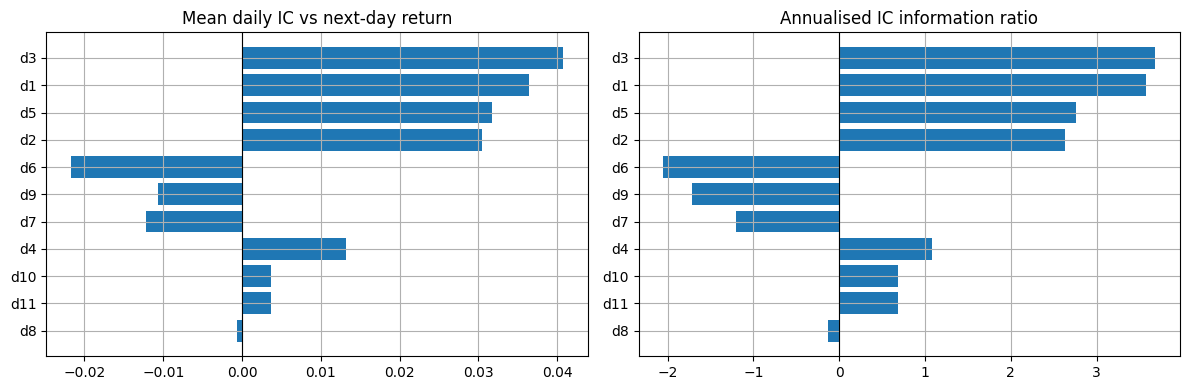

In [13]:
#| label: fig-ic-strength
#| fig-cap: "Signal IC strength and annualised IC information ratio"
order = stats["ic_ann_ic_ir"].abs().sort_values(ascending=False).index
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].barh(order[::-1], stats.loc[order[::-1], "ic_mean_ic"])
ax[0].axvline(0, color="k", lw=0.8); ax[0].set_title("Mean daily IC vs next-day return")
ax[1].barh(order[::-1], stats.loc[order[::-1], "ic_ann_ic_ir"])
ax[1].axvline(0, color="k", lw=0.8); ax[1].set_title("Annualised IC information ratio")
plt.tight_layout(); plt.show()

### 2.5 IC stability over time

A good signal has consistent IC, not in one regime. Plot the rolling-mean IC of the 11 signals

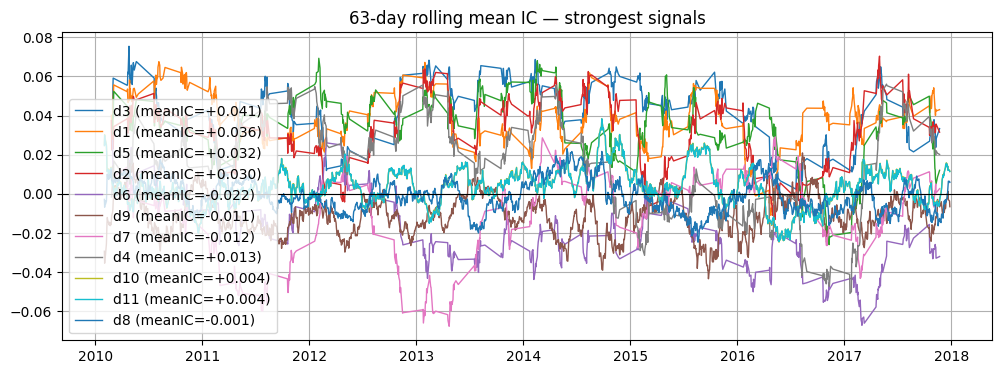

In [14]:
#| label: fig-ic-stability
#| fig-cap: "IC stability over time (rolling mean IC)"
fig, ax = plt.subplots()
for c in order:
    s = ic_series[c]
    if len(s) == 0: continue
    idx = to_dt(pd.Series(s.index))
    ax.plot(idx.values, pd.Series(s.values).rolling(63, min_periods=20).mean(),
            label=f"{c} (meanIC={s.mean():+.3f})", lw=1)
ax.axhline(0, color="k", lw=0.8)
ax.set_title("63-day rolling mean IC — strongest signals"); ax.legend(); plt.show()

### 2.6 Distribution of signals

For each signal, clipped to robust quantiles for readability.

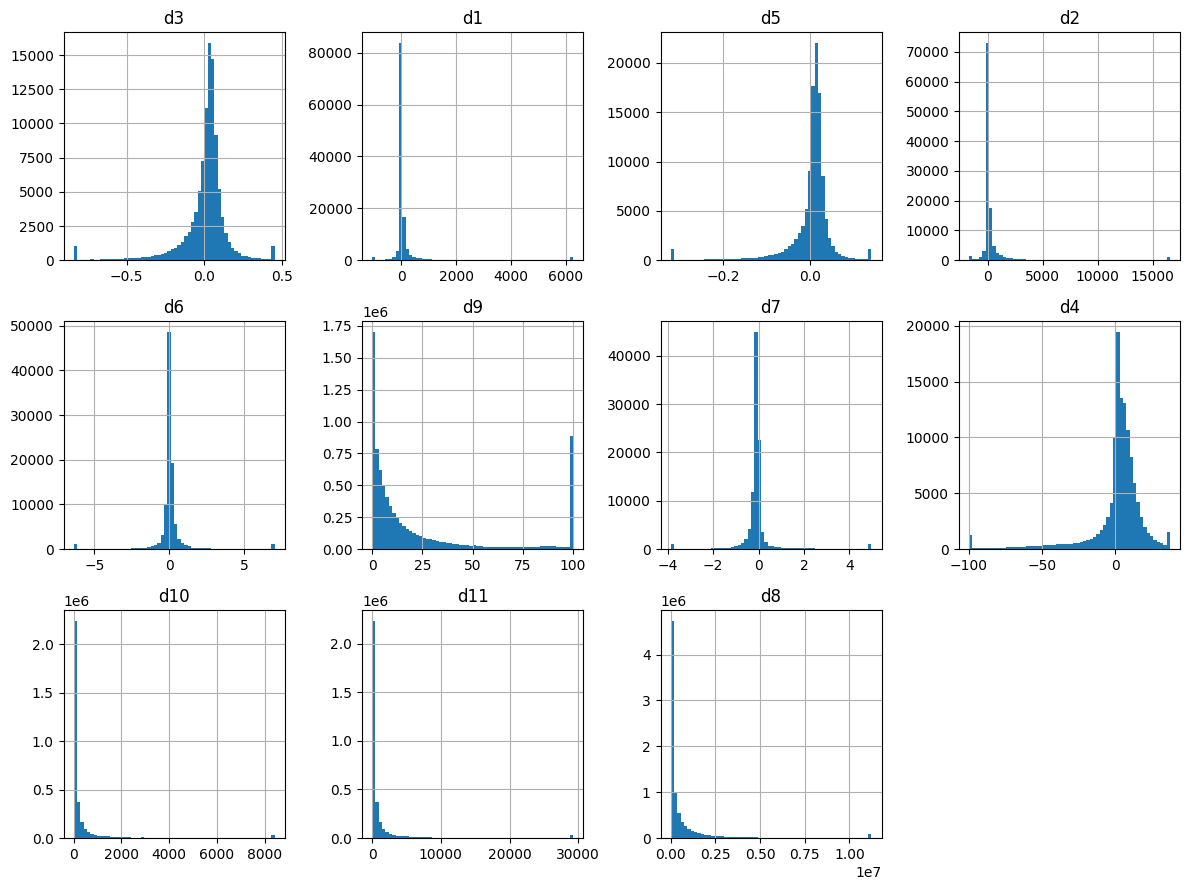

In [15]:
#| label: fig-signal-dist
#| fig-cap: "Signal distributions (robust-quantile clipped)"
sigs = list(order) # all signals, ranked by |IC IR|
ncols = 4
nrows = 3
fig, ax = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes = ax.flatten()
for a, c in zip(axes, sigs):
    v = panel_df[c].dropna()                # panel_df is the wide panel -> one column per signal
    lo, hi = v.quantile(0.01), v.quantile(0.99)
    a.hist(v.clip(lo, hi), bins=60); a.set_title(c)
for a in axes[len(sigs):]:                  # hide any leftover empty axes
    a.axis("off")
plt.tight_layout(); plt.show()

Signals **d3,d4,d5,d6,d7** generally show symmetrical distribution, even though with high kurtosis, we could potentially applly z-score or StandardScalar. 

Signals **d1,d2,d8,d9,d10,d11** generally show skewed or zero-inflated distribution, we could potentially applly min-max scaler. 

### 2.7 Missing-value (NaN) per signal

,n_rows,n_nan,pct_missing_val
signal,,,
d3,127266,27333,21.477
d6,127266,24992,19.638
d7,127266,24126,18.957
d5,127266,15063,11.836
d2,127266,14636,11.5
d1,127266,4788,3.762
d4,127266,4673,3.672
d8,8345449,0,0
d9,8159505,0,0


signals with NaNs: ['d1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7']


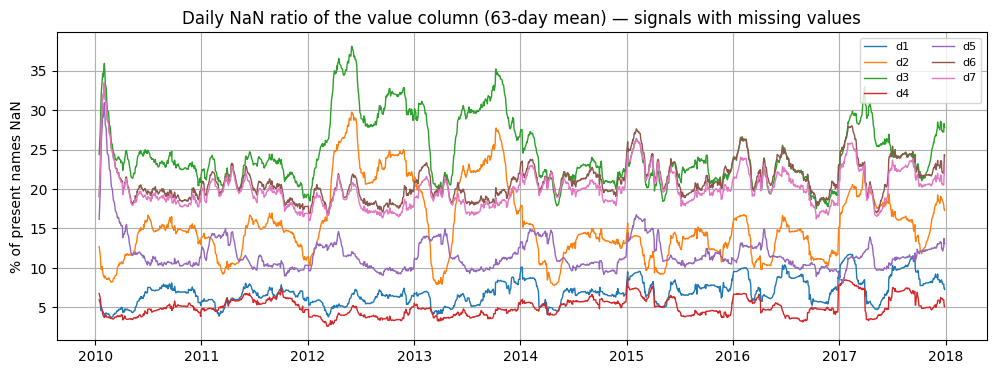

In [16]:
#| label: fig-nan-by-signal
#| fig-cap: "Missing-value rate per signal"
# NaN ratio of the value column per signal (on the de-duplicated file, so it matches the
# numbers used everywhere else). 'NaN in file' = a row exists for that (date, security) but
# the value is blank -- distinct from the row being ABSENT (no row at all), which the
# coverage column (pct_tradable_covered) captures.
nan_tbl = stats[["n_rows", "pct_missing_val"]].copy()
nan_tbl["n_nan"] = (nan_tbl["n_rows"] * nan_tbl["pct_missing_val"] / 100).round().astype("int64")
display(nan_tbl[["n_rows", "n_nan", "pct_missing_val"]].sort_values("pct_missing_val", ascending=False))

# Stability over time: re-read only the signals that actually have NaNs and plot the
# 63-day-smoothed daily share of that day's present names whose value is missing. A flat
# line = uniform sparsity (benign); a ramp or a block = a regime with little/no data.
have_nan = stats.index[stats["pct_missing_val"] > 0].tolist()
print("signals with NaNs:", have_nan)
fig, ax = plt.subplots(figsize=(12, 4))
for f in DS_FILES:
    col = pd.read_csv(os.path.join(DATA_DIR, f), nrows=0).columns[-1]
    if col not in have_nan:
        continue
    df, _ = load_dataset(f)
    by = df.groupby("data_date")[col].apply(lambda s: s.isna().mean() * 100)
    ax.plot(to_dt(pd.Series(by.index)).values,
            pd.Series(by.values).rolling(63, min_periods=10).mean(), lw=1, label=col)
    del df; gc.collect()
ax.set_title("Daily NaN ratio of the value column (63-day mean) — signals with missing values")
ax.set_ylabel("% of present names NaN"); ax.legend(ncol=2, fontsize=8); plt.show()

### 2.8 Securities with most NaNs

In [17]:
#| label: out-nan-by-security
nan_by_sec = {}
for f in DS_FILES:
    df, col = load_dataset(f)
    nan_by_sec[col] = df.groupby("security_id")[col].apply(lambda s: s.isna().sum())
    del df
    gc.collect()

for col, sec_nan in nan_by_sec.items():
    total = len(nan_by_sec[col])
    top10 = (sec_nan[sec_nan > 0] / total * 100).sort_values(ascending=False).head(10)
    if len(top10) == 0:
        print(f"\n{col}: no NaNs")
        continue
    print(f"\n{col} — top 10 securities by NaN %:")
    print(top10.round(3).to_frame("pct_nan"))


d1 — top 10 securities by NaN %:
             pct_nan
security_id         
2238601        0.491
8674501        0.491
22017501       0.491
22417901       0.491
5203601        0.491
8673101        0.491
806001         0.491
809701         0.491
8669001        0.491
2621201        0.491

d2 — top 10 securities by NaN %:
             pct_nan
security_id         
8661601        0.491
8660901        0.491
25481401       0.491
1843401        0.491
22417901       0.491
22017501       0.491
2238601        0.491
8863501        0.491
2621201        0.491
8674501        0.491

d3 — top 10 securities by NaN %:
             pct_nan
security_id         
5980701        0.491
809201         0.491
3393001        0.491
3394201        0.491
3427401        0.491
8661601        0.491
8660901        0.491
1038801        0.491
3523901        0.491
3535501        0.491

d4 — top 10 securities by NaN %:
             pct_nan
security_id         
3256201        0.445
2238601        0.368
7320501        0.322
592

### 2.9 Colinearity between signals

Built on the (de-duplicated) per-signal slices collected above, outer-joined into one wide panel over
all dates. Highly correlated signals carry duplicate information — useful to know before combining them,
to avoid one theme dominating the alpha. We use **rank** (Spearman) correlation since several signals
are heavy-tailed.

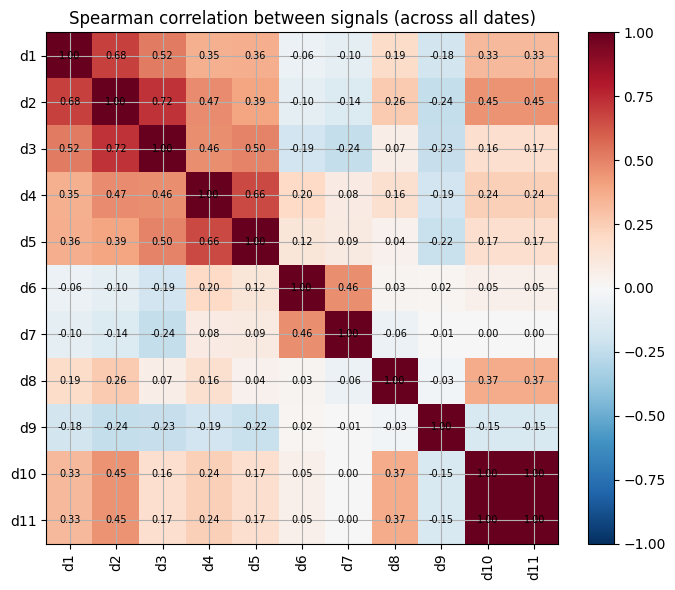

In [18]:
#| label: fig-collinearity
#| fig-cap: "Signal collinearity (Spearman rank correlation)"
# Build a wide correlation panel by outer-joining per-signal slices collected above.
sig_cols = [c for c in panel_df.columns if c not in ("data_date", "security_id")]
corr = panel_df[sig_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(sig_cols))); ax.set_xticklabels(sig_cols, rotation=90)
ax.set_yticks(range(len(sig_cols))); ax.set_yticklabels(sig_cols)
for (i, j), z in np.ndenumerate(corr.values):
    ax.text(j, i, f"{z:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Spearman correlation between signals (across all dates)")
fig.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

### 2.10 Investigate 1.0 correlation between d10 and d11

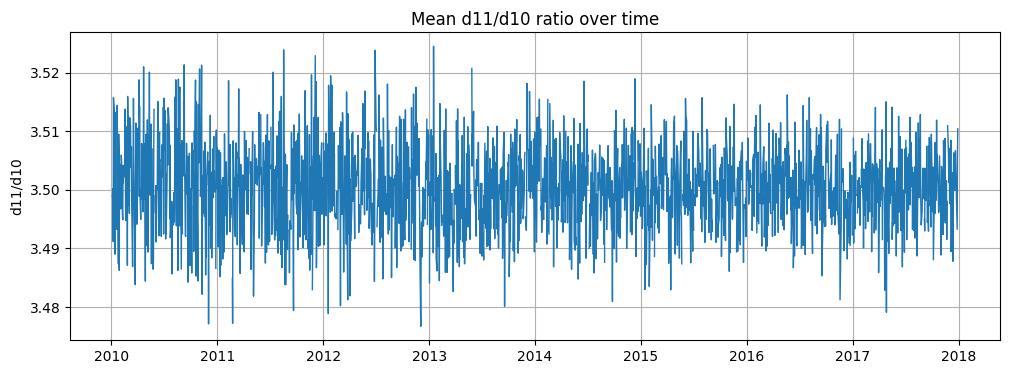

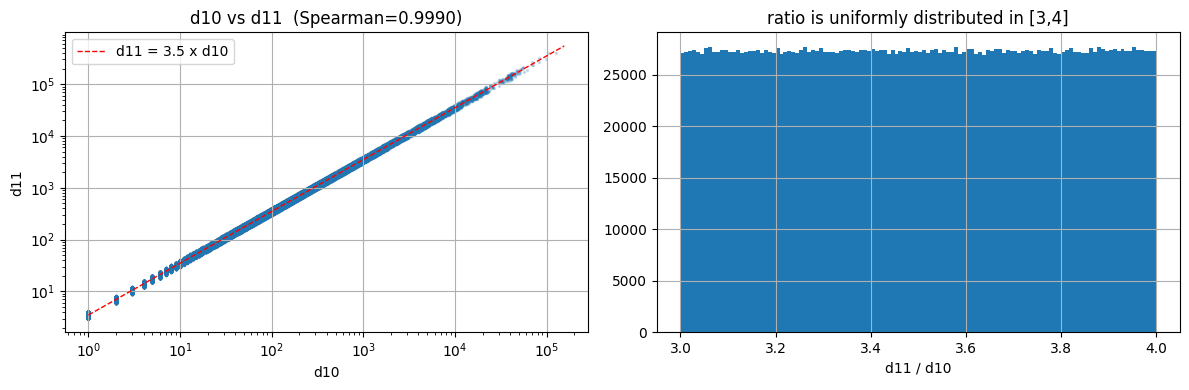

In [19]:
#| label: fig-d10-d11
#| fig-cap: "d10 is identical to d11 (redundant signal)"
b = panel_df[["d10", "d11"]].dropna()
s = b.sample(50000, random_state=0)       

# plot d11/d10 over time to visualize
fig, ax = plt.subplots(figsize=(12, 4))
panel_df["date"] = to_dt(panel_df.data_date)
by = panel_df.groupby("date").apply(lambda g: (g.d11 / g.d10.replace(0, np.nan)).dropna().mean())
ax.plot(by.index, by.values, lw=1)
ax.set_title("Mean d11/d10 ratio over time")
ax.set_ylabel("d11/d10")
plt.show()   

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# 1) log-log scatter: if d11 is just a rescale of d10, points fall on a single line
ax[0].scatter(s.d10, s.d11, s=2, alpha=0.2)
lo, hi = 1, b.d10.max()
ax[0].plot([lo, hi], [3.5*lo, 3.5*hi], "r--", lw=1, label="d11 = 3.5 x d10")
ax[0].set(xscale="log", yscale="log", xlabel="d10", ylabel="d11",
          title=f"d10 vs d11  (Spearman={b.d10.corr(b.d11, method='spearman'):.4f})")
ax[0].legend()
# 2) histogram of the ratio uniformly distributed between 3 and 4
ax[1].hist((b.d11 / b.d10.replace(0, np.nan)).dropna(), bins=120)
ax[1].set(xlabel="d11 / d10", title="ratio is uniformly distributed in [3,4]")
plt.tight_layout(); plt.show()

### 2.11 Investigate highly correlated signal pairs

In [20]:
#| label: tbl-corr-methods
#| tbl-cap: "Pearson vs winsorised-Pearson vs Spearman on highly-correlated pairs"
# Some pairs look uncorrelated under raw Pearson but are strongly RANK-correlated: the
# relationship is monotone but non-linear, and heavy tails wreck the linear correlation.
# Compare raw Pearson vs winsorised (1/99%) Pearson vs Spearman to see it.
def winsor(s, p=0.01):
    lo, hi = s.quantile(p), s.quantile(1 - p)
    return s.clip(lo, hi)

rows = []
for a, c in [("d1", "d2"), ("d2", "d3"), ("d4", "d5")]:
    m = panel_df[[a, c]].dropna()
    x, y = m[a], m[c]
    rows.append(dict(pair=f"{a}~{c}", n_both=len(m),
                     pearson_raw=round(x.corr(y), 3),
                     pearson_winsor=round(winsor(x).corr(winsor(y)), 3),
                     spearman=round(x.corr(y, method="spearman"), 3),
                     skew_a=round(x.skew(), 1), skew_b=round(y.skew(), 1)))
display(pd.DataFrame(rows).set_index("pair"))

,n_both,pearson_raw,pearson_winsor,spearman,skew_a,skew_b
pair,,,,,,
d1~d2,112630,0.66,0.815,0.682,28.1,47.3
d2~d3,99933,-0,0.152,0.724,48,313.5
d4~d5,108624,-0,0.549,0.657,-121.5,323.2


**Pearson**: Measures linear relationships. It uses raw data values. It is highly sensitive to outliers.

**Winsorized Pearson**: Measures linear relationships. It modifies extreme values to a set percentile. It limits outlier impact.

**Spearman**: Measures monotonic (trend) relationships. It converts raw data values into ranks. It resists outlier impact entirely.

For d1,d2 pair, they have very high winsorized Pearson correlation around 0.815, which means that after eliminating outlier effects, the signals are highly correlated.

For d2,d3 pair, even winsorised Pearson stays low around 0.15 while Spearman is around 0.72, so there exists a non-linear but monotone relationship (d3 is likely a heavily compressed transform of d2, skew is around 313).

For d4,d5 pair, they have low raw Pearson correlation but high Spearman and 
winsorized Pearson correlation. This means that the signals are still  correlated. 

## 3 Risk Factors `rf1`–`rf6`
### 3.1 Load risk factors

In [21]:
#| label: tbl-rf-load
#| tbl-cap: "Risk factors rf1–rf6: load and summary"
rf = pd.concat([pd.read_csv(os.path.join(DATA_DIR, f)) for f in RF_FILES], ignore_index=True)
rf = rf.drop_duplicates(["data_date", "security_id"])
rf_cols = [c for c in rf.columns if c.startswith("rf")]
print("risk factor frame:", rf.shape, "| factors:", rf_cols)
print("date range:", rf.data_date.min(), "to", rf.data_date.max())
display(rf[rf_cols].describe().T[["mean","std","min","25%","50%","75%","max"]])
print("\npct missing per factor:")
print((rf[rf_cols].isna().mean()*100).round(3))

risk factor frame: (8800015, 8) | factors: ['rf1', 'rf2', 'rf3', 'rf4', 'rf5', 'rf6']
date range: 20100104 to 20171229


,mean,std,min,25%,50%,75%,max
rf1,0.0614702,1.16931,-3.068,-0.724,0.057,0.838,3.7
rf2,-0.293111,1.16481,-3.169,-0.902,-0.206,0.373,2.946
rf3,0.565605,1.27,-2.893,-0.461,0.264,1.588,3.034
rf4,0.466896,1.19519,-2.818,-0.405,0.281,1.216,3.278
rf5,-0.0129885,1.11491,-2.976,-0.693,-0.061,0.598,2.976
rf6,-0.503807,1.28526,-3.394,-1.138,-0.245,0.262,2.794



pct missing per factor:
rf1   0
rf2   0
rf3   0
rf4   0
rf5   0
rf6   0
dtype: float64


### 3.2 Correlations between risk factors

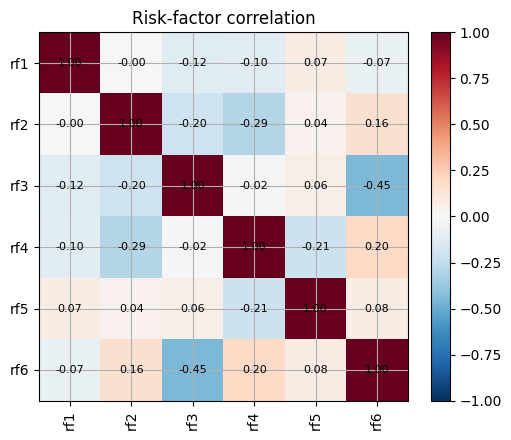

In [22]:
#| label: fig-rf-corr
#| fig-cap: "Risk-factor correlation matrix"
rfc = rf[rf_cols].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(rfc.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(rf_cols))); ax.set_xticklabels(rf_cols, rotation=90)
ax.set_yticks(range(len(rf_cols))); ax.set_yticklabels(rf_cols)
for (i, j), z in np.ndenumerate(rfc.values):
    ax.text(j, i, f"{z:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Risk-factor correlation"); fig.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

###  3.3 Correlations between signals and risk factors

If a signal is strongly correlated with a risk factor, part of its IC may just be a factor bet that we
intend to neutralise away. We estimate the average cross-sectional correlation between each signal and
each risk factor across all dates.

In [23]:
#| label: tbl-sig-rf-corr
#| tbl-cap: "Signal–risk-factor correlations"
rf_s = rf[["data_date","security_id"]+rf_cols]
both = panel_df.merge(rf_s, on=["data_date","security_id"], how="inner")
rows = []
for c in sig_cols:
    rows.append({rfx: both[[c, rfx]].dropna().pipe(
        lambda d: d[c].corr(d[rfx], method="spearman") if len(d) > 50 else np.nan)
        for rfx in rf_cols})
sig_rf = pd.DataFrame(rows, index=sig_cols)
display(sig_rf.round(3))

,rf1,rf2,rf3,rf4,rf5,rf6
d1,-0.004,0.109,-0.238,-0.065,0.023,0.264
d2,0.017,0.153,-0.308,-0.101,0.041,0.339
d3,-0.025,0.136,-0.242,0.066,0.049,0.409
d4,-0.022,0.237,-0.31,-0.258,0.232,0.516
d5,-0.029,0.167,-0.326,0.064,0.031,0.564
d6,0.003,0.061,-0.093,-0.072,0.141,0.186
d7,-0.045,0.056,-0.135,0.061,-0.023,0.201
d8,0.242,0.058,-0.102,-0.175,0.075,0.083
d9,0.134,-0.158,0.259,-0.128,0.074,-0.234
d10,-0.027,0.045,-0.092,-0.125,0.059,0.155


None of the signals are highly correlated with any risk factors.